In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.load_data import load_stations, load_income_grid
from src.spatial import reproject_to_metric, create_buffers
from src.modeling import run_regression


In [2]:
stations = load_stations("../data/raw/Stations/emplacement-des-gares-idf/emplacement-des-gares-idf.shp")
stations.head()

,objectid_1,id_gares,nom_gares,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,id_ref_zda,nom_zda,idrefliga,...,tertram,terval,exploitant,idf,principal,x,y,picto,nom_iv,geometry
0,6,105,Boussy-Saint-Antoine,NaN,NaN,62596,Boussy-Saint-Antoine,47924,Boussy-Saint-Antoine,A01842,...,0,0,SNCF,1,0,665628.8216,6.842419e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', '...",Boussy-Saint-Antoine,POINT (2.53313 48.68102)
1,7,106,Boutigny,NaN,NaN,59565,Boutigny,47895,Boutigny,A01842,...,0,0,SNCF,1,0,653894.1827,6.815094e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', '...",Boutigny,POINT (2.37667 48.43449)
2,12,85,Boissise-le-Roi,NaN,NaN,61943,Boissise-le-Roi,45763,Boissise-le-Roi,A01842,...,0,0,SNCF,1,0,668404.6619,6.825587e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', '...",Boissise-le-Roi,POINT (2.57207 48.52975)
3,68,135,Cesson,NaN,NaN,62176,Cesson,42516,Cesson,A01842,...,0,0,SNCF,1,0,670084.3833,6.829491e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', '...",Cesson,POINT (2.59455 48.56495)
4,79,170,Châtelet-Les Halles,NaN,NaN,474151,Châtelet les Halles,45102,Châtelet les Halles,A01842,...,0,0,RATP,1,1,652093.2251,6.862619e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', '...",Châtelet-Les Halles,POINT (2.34701 48.86182)


In [3]:
stations = reproject_to_metric(stations)
stations = stations[stations["mode"] == "METRO"]
stations.shape


(405, 27)

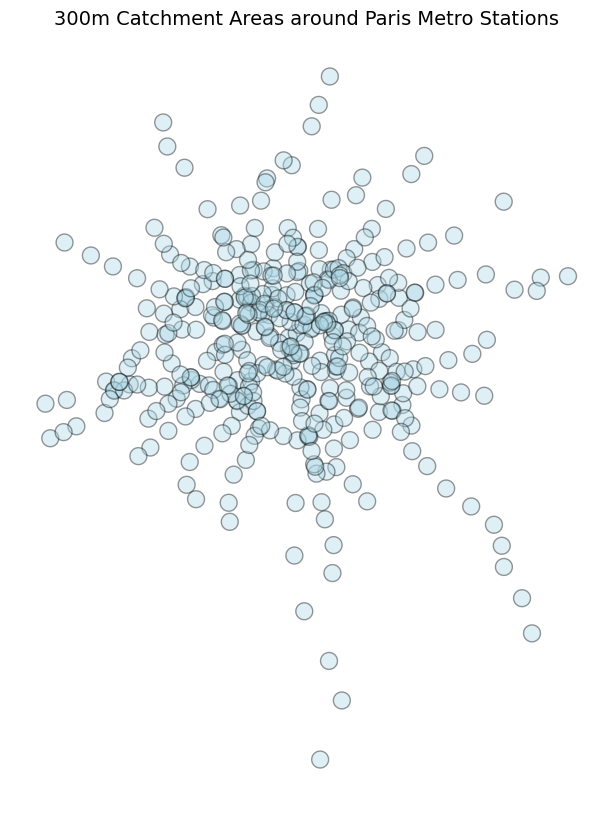

In [7]:
#Buffering
station_buffers = create_buffers(stations, 300)

#Static Map
fig, ax = plt.subplots(figsize=(10, 10))

station_buffers.plot(
    ax=ax,
    alpha=0.4,
    edgecolor="black",
    color="lightblue"
)

ax.set_title("300m Catchment Areas around Paris Metro Stations", fontsize=14)
ax.set_axis_off()

plt.show()

#Interactive Map
m = station_buffers.explore()
m.save("../outputs/WholeNetwork.html")


